<a href="https://colab.research.google.com/github/nobishun/bridge-risk-analysis/blob/main/notebooks/03_eda_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. EDA・クラスター分析

## このノートブックの目的
橋梁データのEDA（探索的データ分析）を行い、変数を標準化した上でK-Meansクラスタリングによって橋梁をグループ分けし、各グループの特徴を解釈します。

## 入力
- `../data/interim/02_bridges_with_detour.gpkg`（`02_detour_calculation.ipynb` の出力）

## 出力
- `../data/processed/03_bridges_clustered.gpkg`
  クラスターラベル（6分類）と道路種別の集約カテゴリを付与したGeoDataFrame（迂回路の経路ジオメトリ`detour_route_wkt`も引き継がれます）


## 0. 環境準備・データ読み込み

Colabでの実行時は、フォルダ直下に02で作成した（02_bridges_with_detour.gpkg）を保存し、bridges_gdfは（bridges_gdf = gpd.read_file("/content/02_bridges_with_detour.gpkg")
）を利用してください。

In [ ]:
import ast

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

# Install japanize_matplotlib if not already installed
try:
    import japanize_matplotlib  # 日本語表示のために必要
except ImportError:
    print("japanize_matplotlibが見つかりません。インストールします...")
    !pip install japanize_matplotlib
    import japanize_matplotlib
    print("japanize_matplotlibがインストールされ、インポートされました。")

japanize_matplotlibが見つかりません。インストールします...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=dc3f4d80a1da52e5f54481dbd2a170f80a29a0fd06a35aa4f2b7926b3522685d
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
japanize_matplotlibがインストールされ、インポートされました。


In [ ]:
#bridges_gdf = gpd.read_file("../data/interim/02_bridges_with_detour.gpkg")
bridges_gdf = gpd.read_file("/content/02_bridges_with_detour.gpkg")
print(f"読み込んだ橋梁数: {len(bridges_gdf)}")
bridges_gdf.head()

読み込んだ橋梁数: 1226


,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m,dpf_title,dpf_lat,dpf_lon,dpf_gyousei_kuiki_shikuchouson_mei,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,dpf_kanrisya_kubun,dpf_kiroku_hantei_kubun,dpf_syuzen_sochi_joukyou,osm_osmid,osm_bridge,osm_highway,osm_lanes,osm_oneway,osm_reversed,osm_length,osm_name,osm_ref,osm_maxspeed,osm_access,osm_tunnel,osm_width,osm_est_width,osm_junction,osm_area,index_right,voronoi_title,traffic_count_24h_auto,osm_geometry_line_wkt,osm_geometry_point_wkt,detour_length_m,detour_path_nodes,detour_route_wkt,geometry
0,2,玉野橋,617126346,617125876,0,0.36,玉野橋,35.60737,139.64151,世田谷区,1966,7.4,22.2,5,3,1,"[51372377, 48585741, 1126629423]",yes,residential,None,True,False,121.201665,None,None,None,None,None,None,None,None,None,1424,交通調査基本区間番号:13304660040 (一般国道４６６号（第三京浜道路）),64469.0,"LINESTRING (-17390.10164 -43602.365488, -17389...",POINT (-17379.357532 -43542.859268),597.130646,"[617126346, 269668898, 281381332, 2895717415, ...","LINESTRING (139.6413898 35.6068357, 139.641520...",POINT (-17379.096 -43543.111)
1,3,矢澤橋,537929170,537929320,0,4.80,矢澤橋,35.61337,139.64220,世田谷区,1960,6.1,7.1,5,1,0,"[177782884, 55450109, 42939972]",yes,residential,None,True,False,11.959728,None,None,None,None,None,None,None,None,None,1389,交通調査基本区間番号:13304660020 (一般国道４６６号),48526.0,"LINESTRING (-17313.919212 -42876.502706, -1731...",POINT (-17319.905341 -42876.263124),123.020137,"[537929170, 537929165, 537929267, 537929320]","LINESTRING (139.6422151 35.6133798, 139.642212...",POINT (-17315.289 -42877.587)
2,4,無名五十七号橋,811135988,1033248469,0,4.09,無名五十七号橋,35.65581,139.63255,世田谷区,1950,5.3,2.6,5,2,1,"[1454310453, 1454310454, 41176245]",yes,residential,None,False,True,69.720368,None,None,None,None,None,None,None,None,None,1386,交通調査基本区間番号:13601180090 (調布経堂停車場線),10873.0,"LINESTRING (-18189.033518 -38136.600681, -1817...",POINT (-18183.55651 -38169.310893),173.074616,"[811135988, 811135982, 811129543, 1033248469]","LINESTRING (139.6324484 35.6560883, 139.631962...",POINT (-18179.897 -38167.495)
3,5,中ノ橋,563748534,822683230,0,23.75,中ノ橋,35.69250,139.67889,中野区,2000,10.3,15.0,5,2,1,"[44358025, 44358022, 44358015]",yes,unclassified,None,False,False,58.127737,中ノ橋,None,None,None,None,None,None,None,None,1620,交通調査基本区間番号:13403170230 (環状六号線),34486.0,"LINESTRING (-13979.72641 -34109.403722, -13975...",POINT (-13964.753522 -34084.664614),162.609045,"[563748534, 670401581, 563748916, 563748907, 5...","LINESTRING (139.6788671 35.6924568, 139.678954...",POINT (-13977.646 -34104.614)
4,7,大井北部陸橋(ランプ部２),582140959,7093114606,0,40.83,大井北部陸橋(ランプ部２),35.59491,139.75565,品川区,1973,11.8,90.6,2,2,8,729484782,yes,tertiary,2,True,False,31.487573,None,None,None,None,None,None,None,None,None,2325,交通調査基本区間番号:13303570250 (一般国道３５７号),47937.0,"LINESTRING (-7027.818025 -44900.038352, -7059....",POINT (-7043.56124 -44898.99972),78.130461,"[582140959, 13439528430, 7104540462, 134395284...","LINESTRING (139.7557748 35.5952666, 139.755574...",POINT (-7039.158 -44939.591)


## 1. 分析用データフレームの作成

In [ ]:
ANALYSIS_COLUMNS = [
    "dpf_index", "bridge_name",
    "dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou",
    "osm_highway", "osm_oneway",
    "traffic_count_24h_auto", "detour_length_m",
]
analysis_df = bridges_gdf[ANALYSIS_COLUMNS].copy()
analysis_df["dpf_kasetsu_nendo"] = pd.to_numeric(analysis_df["dpf_kasetsu_nendo"], errors="coerce").astype(int)

analysis_df.describe(include="all")


,dpf_index,bridge_name,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,osm_highway,osm_oneway,traffic_count_24h_auto,detour_length_m
count,1226.000000,1226,1226.000000,1226.000000,1226.000000,1226,1226,1226.000000,1226.000000
unique,NaN,1028,NaN,NaN,NaN,16,2,NaN,NaN
top,NaN,富士見橋,NaN,NaN,NaN,tertiary,False,NaN,NaN
freq,NaN,9,NaN,NaN,NaN,306,822,NaN,NaN
mean,937.122349,NaN,1975.328711,12.259706,44.311011,NaN,NaN,31106.899674,inf
std,542.152643,NaN,23.214783,8.488276,82.942552,NaN,NaN,22436.254435,NaN
min,2.000000,NaN,1916.000000,0.000000,2.000000,NaN,NaN,99.000000,43.266699
25%,471.250000,NaN,1964.000000,6.000000,11.525000,NaN,NaN,15370.000000,334.659417
50%,928.000000,NaN,1975.000000,9.800000,18.500000,NaN,NaN,26133.000000,585.148661
75%,1408.750000,NaN,1991.000000,15.000000,37.175000,NaN,NaN,39978.000000,1142.268413


## 2. 迂回路長（detour_length_m）の欠損（inf）値の扱い

**検討過程:** 一部の橋ではOSMネットワーク上に迂回路が見つからず`inf`となります。これは実際に迂回路が存在しないというより、OSMデータの結線不備が原因のケースが多いと判断し、**非inf値の中央値で補完**する方針としました（`02`のサンプル地図でも、迂回路が見つかった橋についてはおおむね妥当な経路が得られていることを確認済みです）。


In [ ]:
inf_count = np.isinf(analysis_df["detour_length_m"]).sum()
print(f"迂回路長がinfの橋梁数: {inf_count} / {len(analysis_df)}")

median_detour = analysis_df.loc[~np.isinf(analysis_df["detour_length_m"]), "detour_length_m"].median()
analysis_df["detour_length_m"] = analysis_df["detour_length_m"].replace([np.inf, -np.inf], median_detour)

# 【修正】この時点ではanalysis_df（クラスタリング計算用のコピー）だけを補完しており、
# 保存対象であるbridges_gdf側のdetour_length_mには反映されていなかった。
# そのままだと最終的な成果物(final_analysis_gdf)にinfが残ってしまうため、
# bridges_gdf側にも同じ補完を適用する。
bridges_gdf["detour_length_m"] = bridges_gdf["detour_length_m"].replace([np.inf, -np.inf], median_detour)

print(f"中央値 {median_detour:.1f}m で補完しました（bridges_gdf側にも反映済み）")


迂回路長がinfの橋梁数: 121 / 1226
中央値 534.5m で補完しました（bridges_gdf側にも反映済み）


## 3. 重複データの確認・削除

In [ ]:
dup_mask = analysis_df.duplicated(subset=["bridge_name", "dpf_fukuin", "dpf_kyouchou"], keep=False)
print(f"橋梁名・幅員・橋長が完全一致する重複行: {dup_mask.sum()}件")
if dup_mask.sum() > 0:
    display(analysis_df[dup_mask].sort_values("bridge_name"))

# 完全重複はDPFマッチング処理由来の重複と判断し、後勝ちを除いて1件のみ残す
analysis_df = analysis_df.drop_duplicates(subset=["dpf_index"], keep="first")
print(f"重複削除後の橋梁数: {len(analysis_df)}")


橋梁名・幅員・橋長が完全一致する重複行: 0件
重複削除後の橋梁数: 1226


## 4. カテゴリ変数の確認と道路種別の集約

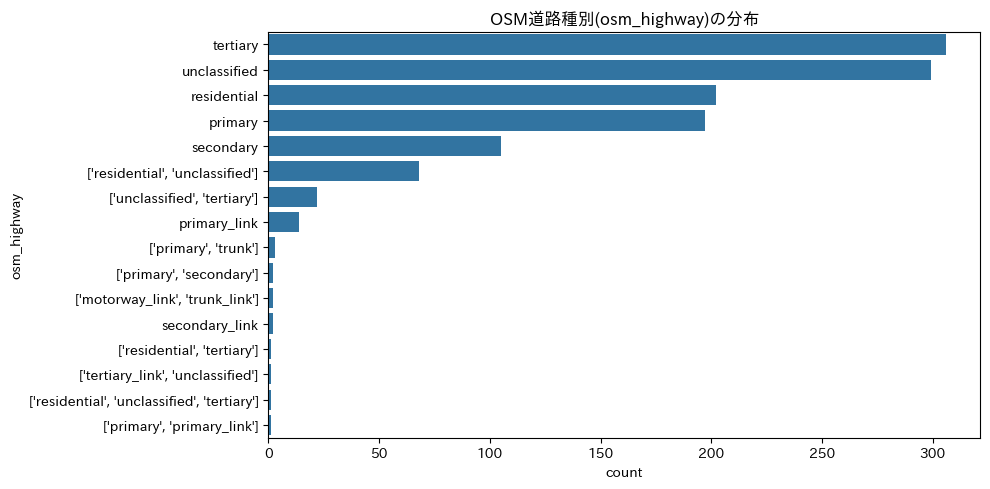

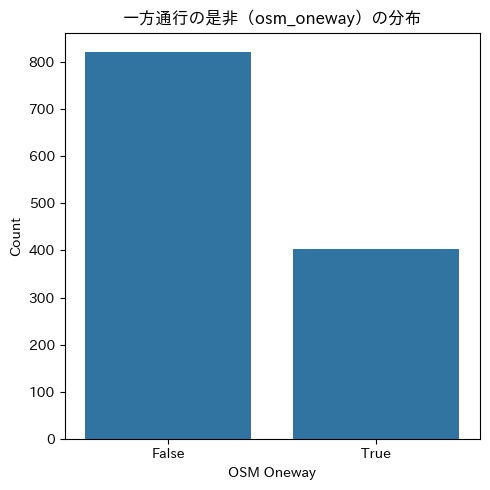

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=analysis_df, y="osm_highway", order=analysis_df["osm_highway"].value_counts().index)
plt.title("OSM道路種別(osm_highway)の分布")
plt.tight_layout()
plt.show()

# Set a larger figure size for better readability
plt.figure(figsize=(5, 5))

# Bar plot for 'osm_oneway'
sns.countplot(data=analysis_df, x='osm_oneway')
plt.title('一方通行の是非（osm_oneway）の分布')
plt.xlabel('OSM Oneway')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**検討過程:** OSMの`highway`タグは種類が多く、リスト形式で複数種別が入っているケースもあるため、以下の基準で1〜5の優先度番号に集約しました（リストの場合は最も上位＝数字が小さいものを採用）。

| 番号 | カテゴリ | 元のタグ |
| :---: | :--- | :--- |
| 1 | 主要道 | primary, motorway, trunk, \*\_link |
| 2 | 二次主要道 | secondary, secondary_link |
| 3 | 一般道路 | tertiary, tertiary_link |
| 4 | 補助道路 | unclassified |
| 5 | 生活道路 | residential |


In [ ]:
HIGHWAY_PRIORITY_MAP = {
    "primary": 1, "motorway": 1, "trunk": 1,
    "primary_link": 1, "motorway_link": 1, "trunk_link": 1,
    "secondary": 2, "secondary_link": 2,
    "tertiary": 3, "tertiary_link": 3,
    "unclassified": 4,
    "residential": 5,
}
DEFAULT_PRIORITY = 99


def normalize_highway_type(highway_value):
    """OSMのhighwayタグ(文字列 or リスト形式の文字列)を優先度カテゴリ番号に集約する。"""
    if isinstance(highway_value, str) and highway_value.startswith("["):
        try:
            values = [str(v) for v in ast.literal_eval(highway_value)]
        except (ValueError, SyntaxError):
            values = [highway_value]
    elif isinstance(highway_value, list):
        values = [str(v) for v in highway_value]
    else:
        values = [str(highway_value)]

    priorities = [HIGHWAY_PRIORITY_MAP.get(v, DEFAULT_PRIORITY) for v in values]
    return min(priorities)


analysis_df["osm_highway_aggregated"] = analysis_df["osm_highway"].apply(normalize_highway_type)
analysis_df["osm_oneway"] = bridges_gdf.loc[analysis_df.index, "osm_oneway"].astype(int)

analysis_df["osm_highway_aggregated"].value_counts().sort_index()


,count
osm_highway_aggregated,
1,219
2,107
3,331
4,367
5,202


## 5. 数値変数の分布・相関確認

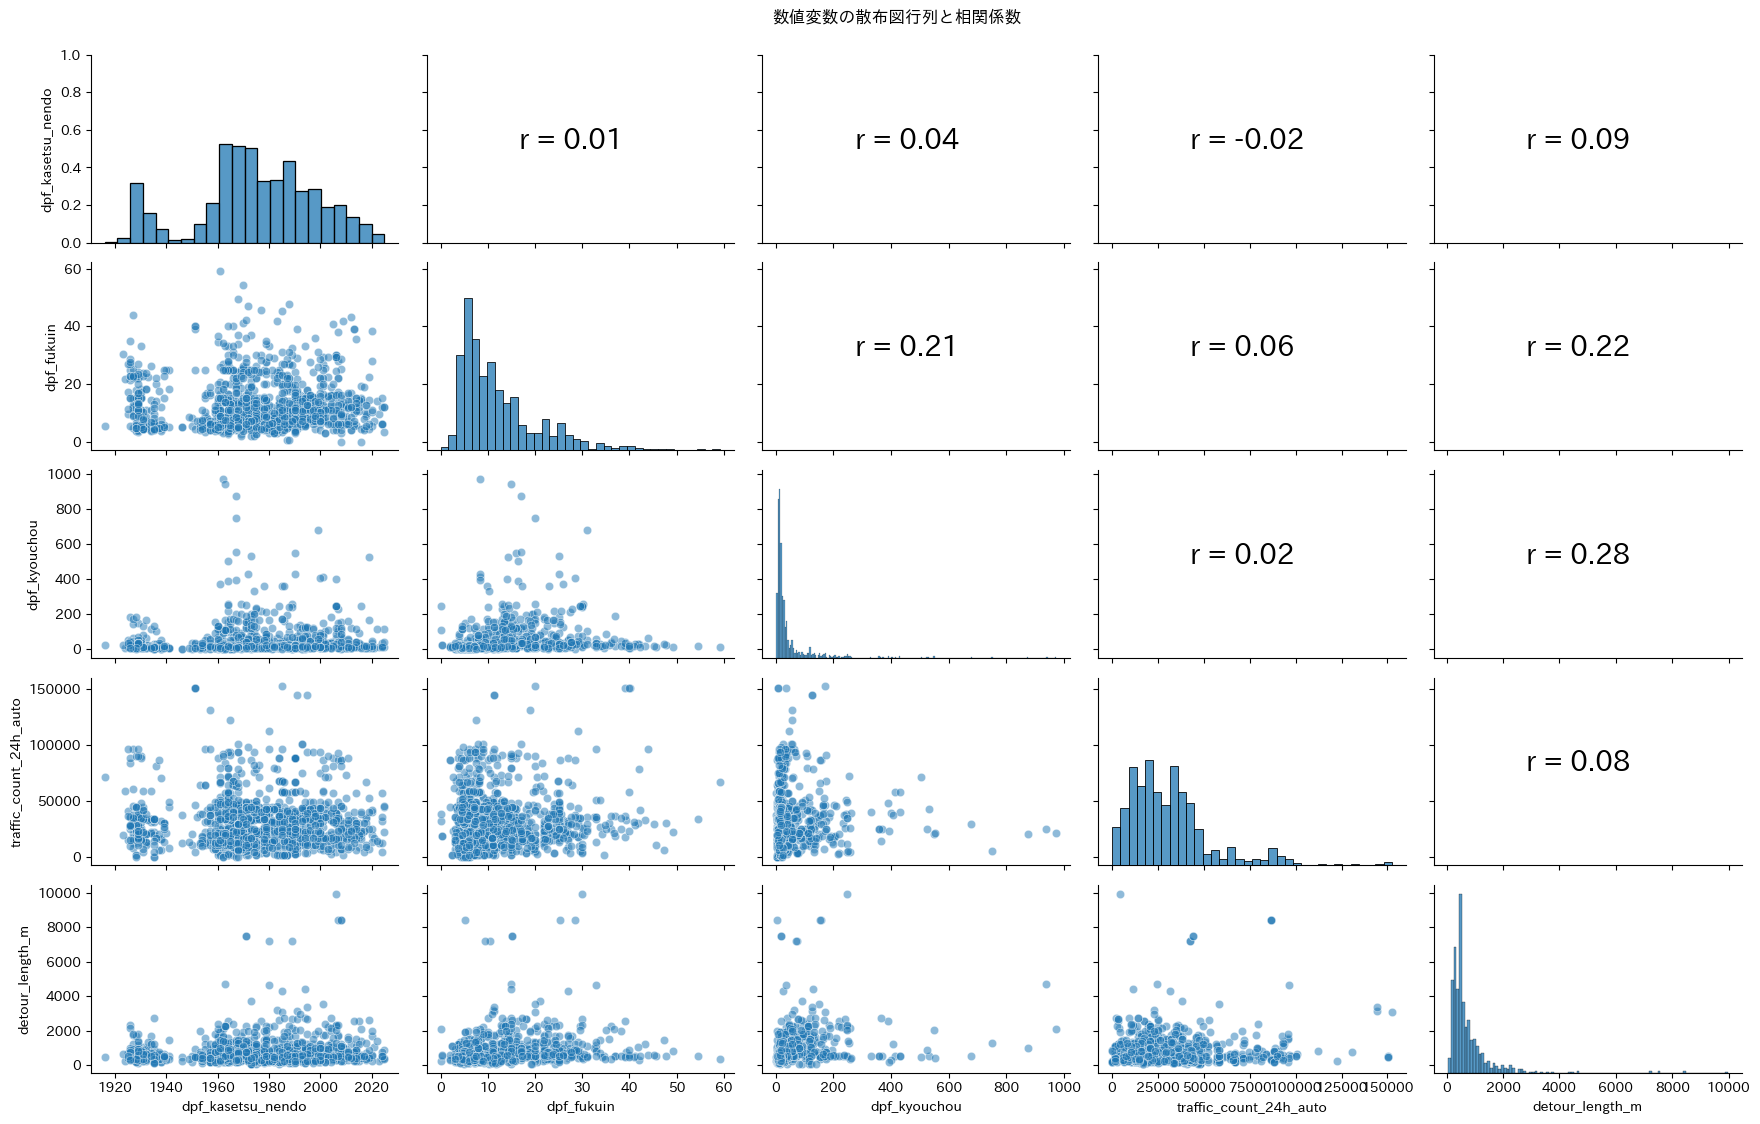

In [ ]:
numeric_cols = ["dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou", "traffic_count_24h_auto", "detour_length_m"]

g = sns.PairGrid(analysis_df[numeric_cols], height=2.2, aspect=1.6)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot, alpha=0.5)
g.map_upper(lambda x, y, **kwargs: plt.gca().annotate(
    f"r = {np.corrcoef(x, y)[0, 1]:.2f}", xy=(0.3, 0.5), xycoords="axes fraction", fontsize=20
))
plt.suptitle("数値変数の散布図行列と相関係数", y=1.02)
plt.show()


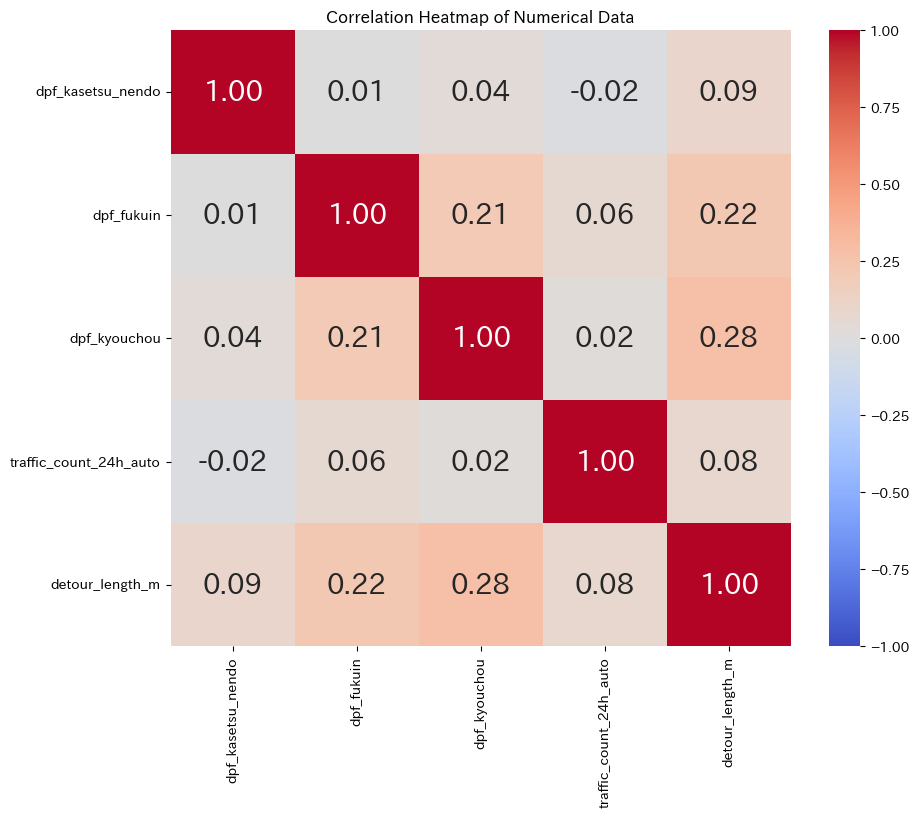

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix from the DataFrame used for pairplot
# This DataFrame already has 'inf' values replaced with NaN
correlation_matrix = analysis_df[numeric_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, annot_kws={'fontsize': 20})
plt.title('Correlation Heatmap of Numerical Data')
plt.show()

## 6. クラスター分析：変数の標準化

In [ ]:
CLUSTERING_COLS = [
    "dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou",
    "osm_oneway", "traffic_count_24h_auto", "detour_length_m", "osm_highway_aggregated",
]
X = analysis_df[CLUSTERING_COLS].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled.head()


,dpf_kasetsu_nendo,dpf_fukuin,dpf_kyouchou,osm_oneway,traffic_count_24h_auto,detour_length_m,osm_highway_aggregated
0,-0.402008,-0.572753,-0.266691,1.426413,1.487580,-0.181459,1.381934
1,-0.660569,-0.725968,-0.448819,1.426413,0.776699,-0.752218,1.381934
2,-1.091505,-0.820254,-0.503096,-0.701059,-0.902207,-0.691959,1.381934
3,1.063174,-0.230966,-0.353534,-0.701059,0.150670,-0.704558,0.620815
4,-0.100353,-0.054180,0.558313,1.426413,0.750436,-0.806258,-0.140304


## 7. クラスター数の検討（エルボー法 & 分布比較）

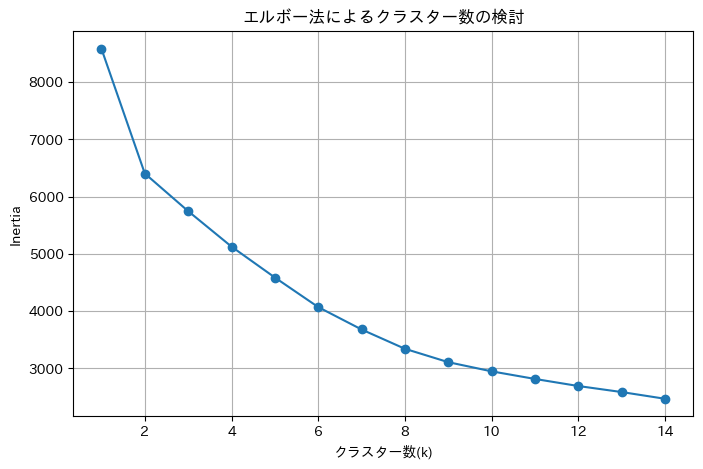

In [ ]:
inertias = []
for k in range(1, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 15), inertias, marker="o")
plt.title("エルボー法によるクラスター数の検討")
plt.xlabel("クラスター数(k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


**検討過程:** エルボー法だけでは明確な「肘」が出にくいデータでしたが、少数クラスターに埋もれてしまう特異なリスク要因（極端に交通量が多い橋、極端に迂回路が長い橋など）を分離して抽出できるかという実務的な観点から、**k=6を採用**しました。粒度の異なる比較として、後段でk=3の結果も参考として確認します。


## 8. k=6でクラスタリングを実行・解釈

In [ ]:
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_scaled)
analysis_df["cluster_6_label"] = kmeans_6.predict(X_scaled)

analysis_df["cluster_6_label"].value_counts().sort_index()


,count
cluster_6_label,
0,105
1,11
2,256
3,436
4,396
5,22


In [ ]:
import pandas as pd

# Define the columns for summary statistics
summary_stats_cols = [
    'dpf_kasetsu_nendo',
    'dpf_fukuin',
    'dpf_kyouchou',
    'traffic_count_24h_auto',
    'detour_length_m'
]

print("### 数値変数のクラスター別要約統計量")
for col in summary_stats_cols:
    print(f"\n#### {col} (クラスター別要約統計量):")
    display(analysis_df.groupby('cluster_6_label')[col].describe())

# Define the columns for count and proportion
count_proportion_cols = [
    'osm_oneway',
    'osm_highway_aggregated'
]

# Re-define Japanese labels for better readability (these were defined in a previous cell)
osm_oneway_labels = {0: '一方通行ではない', 1: '一方通行'}
osm_highway_aggregated_labels = {
    1: '主要道',
    2: '二次主要道',
    3: '一般道路',
    4: '補助道路',
    5: '生活道路',
    99: 'その他'
}

print("\n### カテゴリ変数のクラスター別カウント数と構成比")
for col in count_proportion_cols:
    print(f"\n#### {col} (クラスター別カウント数と構成比):")
    # Calculate counts and proportions
    counts = analysis_df.groupby('cluster_6_label')[col].value_counts().unstack(fill_value=0)
    proportions = analysis_df.groupby('cluster_6_label')[col].value_counts(normalize=True).unstack(fill_value=0)

    # Rename columns for readability using the defined labels
    if col == 'osm_oneway':
        counts = counts.rename(columns=osm_oneway_labels)
        proportions = proportions.rename(columns=osm_oneway_labels)
    elif col == 'osm_highway_aggregated':
        counts = counts.rename(columns=osm_highway_aggregated_labels)
        proportions = proportions.rename(columns=osm_highway_aggregated_labels)

    # Combine counts and proportions for each category into a single DataFrame for display
    combined_df = pd.DataFrame()
    for category in counts.columns:
        combined_df[f'{category} (Count)'] = counts[category]
        combined_df[f'{category} (Proportion)'] = proportions[category].round(3)

    display(combined_df)

### 数値変数のクラスター別要約統計量

#### dpf_kasetsu_nendo (クラスター別要約統計量):


,count,mean,std,min,25%,50%,75%,max
cluster_6_label,,,,,,,,
0,105.0,1972.323810,21.577452,1925.0,1962.0,1969.0,1990.0,2011.0
1,11.0,1990.818182,14.661638,1971.0,1980.0,1989.0,2006.5,2008.0
2,256.0,1976.269531,20.151816,1923.0,1965.0,1973.0,1988.0,2020.0
3,436.0,1993.658257,12.704428,1972.0,1984.0,1992.0,2001.0,2025.0
4,396.0,1954.659091,16.684638,1916.0,1935.0,1961.0,1968.0,1975.0
5,22.0,1979.772727,16.866229,1961.0,1967.0,1973.5,1990.0,2019.0



#### dpf_fukuin (クラスター別要約統計量):


,count,mean,std,min,25%,50%,75%,max
cluster_6_label,,,,,,,,
0,105.0,11.060952,8.058291,2.0,6.000,8.4,14.20,40.1
1,11.0,19.481818,9.534025,5.1,12.750,15.2,27.75,33.0
2,256.0,22.400391,9.738468,0.0,14.500,22.1,27.50,59.2
3,436.0,9.591972,4.260236,0.4,6.200,9.0,12.00,26.6
4,396.0,8.491414,5.333484,2.0,5.000,6.5,11.00,34.9
5,22.0,17.068182,6.901441,8.3,11.225,16.5,22.25,31.0



#### dpf_kyouchou (クラスター別要約統計量):


...

,count,mean,std,min,25%,50%,75%,max
cluster_6_label,,,,,,,,
0,105.0,723.832588,614.229087,154.204976,354.699878,534.542581,826.344903,3380.773452
1,11.0,7091.579651,1860.996402,4309.136435,5939.108863,7506.839856,8409.620619,9960.071115
2,256.0,1020.786208,703.277337,43.266699,534.542581,758.980693,1367.773521,3742.529212
3,436.0,589.575340,432.435297,82.705508,289.226343,513.462538,733.732894,3165.442962
4,396.0,555.374268,353.349095,97.283223,286.287285,494.019847,706.316919,2732.839134
5,22.0,1116.634722,1089.067503,184.566465,534.434930,534.542581,1241.698410,4693.564257



### カテゴリ変数のクラスター別カウント数と構成比

#### osm_oneway (クラスター別カウント数と構成比):


,一方通行ではない (Count),一方通行ではない (Proportion),一方通行 (Count),一方通行 (Proportion)
cluster_6_label,,,,
0,67,0.638,38,0.362
1,1,0.091,10,0.909
2,28,0.109,228,0.891
3,369,0.846,67,0.154
4,352,0.889,44,0.111
5,5,0.227,17,0.773



#### osm_highway_aggregated (クラスター別カウント数と構成比):


,主要道 (Count),主要道 (Proportion),二次主要道 (Count),二次主要道 (Proportion),一般道路 (Count),一般道路 (Proportion),補助道路 (Count),補助道路 (Proportion),生活道路 (Count),生活道路 (Proportion)
cluster_6_label,,,,,,,,,,
0,10,0.095,3,0.029,39,0.371,33,0.314,20,0.190
1,7,0.636,2,0.182,2,0.182,0,0.000,0,0.000
2,176,0.688,50,0.195,26,0.102,3,0.012,1,0.004
3,3,0.007,15,0.034,141,0.323,186,0.427,91,0.209
4,7,0.018,35,0.088,120,0.303,145,0.366,89,0.225
5,16,0.727,2,0.091,3,0.136,0,0.000,1,0.045


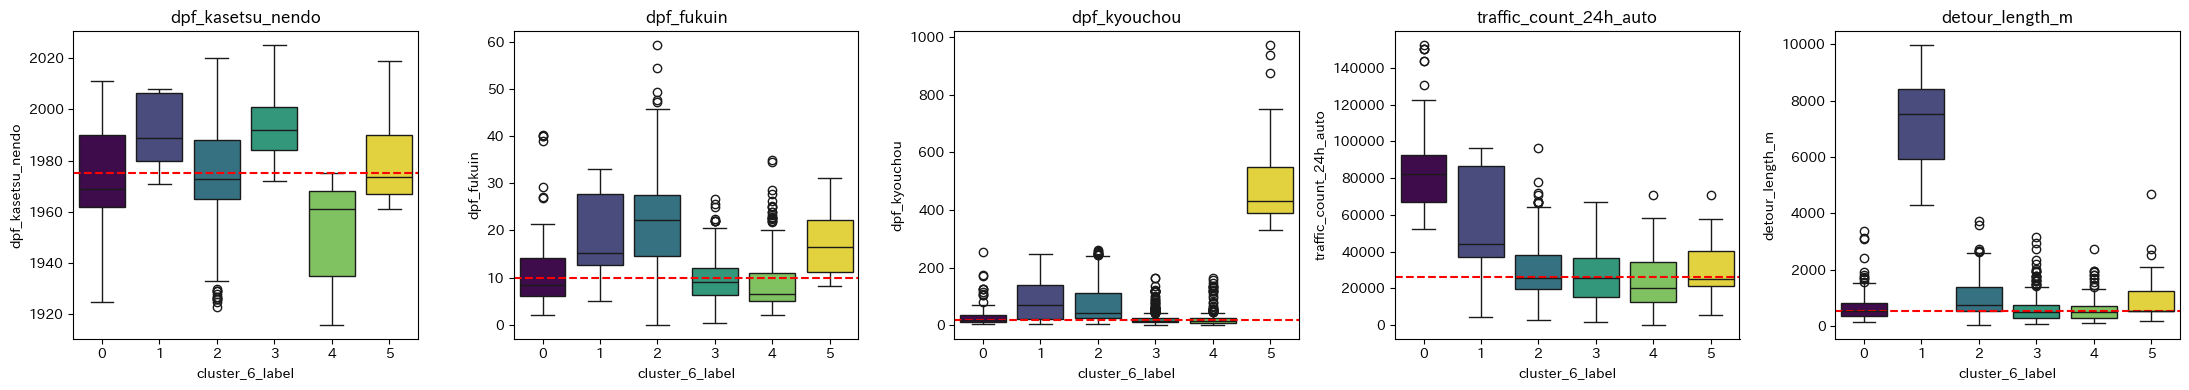

In [ ]:
box_cols = ["dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou", "traffic_count_24h_auto", "detour_length_m"]

fig, axes = plt.subplots(1, len(box_cols), figsize=(22, 4))
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=analysis_df, x="cluster_6_label", y=col, hue="cluster_6_label", palette="viridis", legend=False, ax=ax)
    ax.axhline(analysis_df[col].median(), color="red", linestyle="--")
    ax.set_title(col)
plt.tight_layout()
plt.show()


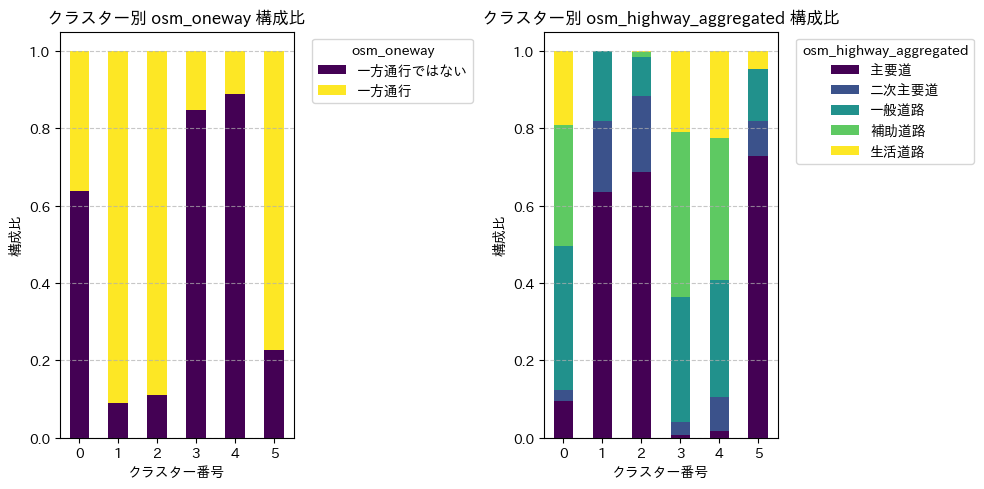

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Columns for which to create stacked bar charts
stacked_bar_cols = [
    'osm_oneway',
    'osm_highway_aggregated'
]

# Define Japanese labels for osm_oneway for better readability
osm_oneway_labels = {0: '一方通行ではない', 1: '一方通行'}

# Define Japanese labels for osm_highway_aggregated for better readability
osm_highway_aggregated_labels = {
    1: '主要道',
    2: '二次主要道',
    3: '一般道路',
    4: '補助道路',
    5: '生活道路',
    99: 'その他'
}

plt.figure(figsize=(10, 5))

for i, col in enumerate(stacked_bar_cols):
    plt.subplot(1, len(stacked_bar_cols), i + 1)

    # Calculate counts for each category within each cluster
    if col == 'osm_oneway':
        # Map numerical values to descriptive labels for better visualization
        plot_data = analysis_df.groupby('cluster_6_label')[col].value_counts(normalize=True).unstack().fillna(0)
        plot_data = plot_data.rename(columns=osm_oneway_labels)
    elif col == 'osm_highway_aggregated':
        # Map numerical values to descriptive labels for better visualization
        plot_data = analysis_df.groupby('cluster_6_label')[col].value_counts(normalize=True).unstack().fillna(0)
        plot_data = plot_data.rename(columns=osm_highway_aggregated_labels)
    else:
        plot_data = analysis_df.groupby('cluster_6_label')[col].value_counts(normalize=True).unstack().fillna(0)

    plot_data.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
    plt.title(f'クラスター別 {col} 構成比')
    plt.xlabel('クラスター番号')
    plt.ylabel('構成比')
    plt.xticks(rotation=0)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

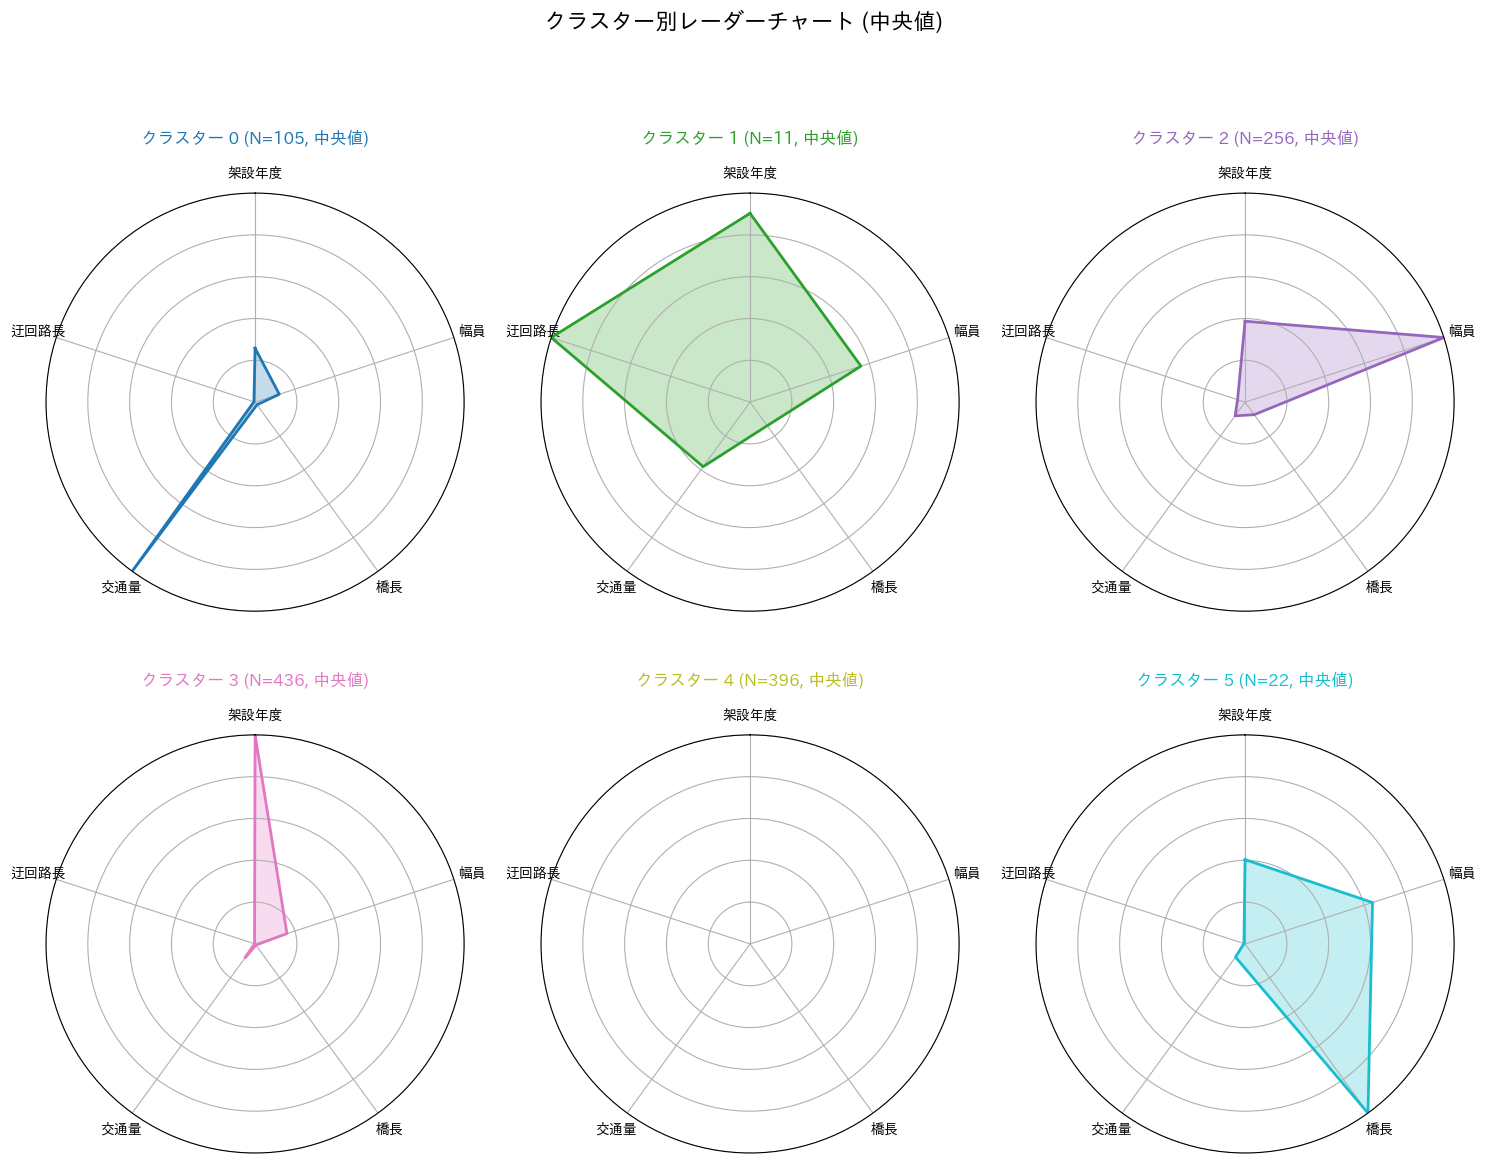

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import japanize_matplotlib # 日本語表示のために必要
import matplotlib.colors as mcolors

# Define the features for the radar chart
# osm_oneway and osm_highway_aggregated have been removed as per the user request.
radar_features = [
    'dpf_kasetsu_nendo',
    'dpf_fukuin',
    'dpf_kyouchou',
    'traffic_count_24h_auto',
    'detour_length_m'
]

# Ensure 'cluster_6_label' is treated as a numerical type for grouping
analysis_df['cluster_6_label'] = analysis_df['cluster_6_label'].astype(int)

# Calculate median values for each cluster
cluster_medians = analysis_df.groupby('cluster_6_label')[radar_features].median()

# Calculate the count of data points for each cluster
cluster_counts = analysis_df['cluster_6_label'].value_counts().sort_index()

# Normalize the median values for radar chart
normalized_cluster_medians = pd.DataFrame(index=cluster_medians.index, columns=cluster_medians.columns)

for feature in radar_features:
    min_val = cluster_medians[feature].min()
    max_val = cluster_medians[feature].max()

    if max_val == min_val:
        # Avoid division by zero if all median values for a feature are the same
        normalized_cluster_medians[feature] = 0.5 # Assign a neutral value
    else:
        # Min-max normalization to scale values between 0 and 1
        normalized_cluster_medians[feature] = (cluster_medians[feature] - min_val) / (max_val - min_val)

# Prepare for plotting
num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Complete the loop for the radar chart

# Add the first value to the end to close the circle for each cluster's data
plot_data = normalized_cluster_medians.values
plot_data = np.concatenate((plot_data, plot_data[:, [0]]), axis=1)

# Japanese feature names for labels
# osm_oneway and osm_highway_aggregated have been removed
japanese_feature_names = {
    'dpf_kasetsu_nendo': '架設年度',
    'dpf_fukuin': '幅員',
    'dpf_kyouchou': '橋長',
    'traffic_count_24h_auto': '交通量',
    'detour_length_m': '迂回路長'
}
radar_labels = [japanese_feature_names[feature] for feature in radar_features]
radar_labels += radar_labels[:1] # Complete the loop for labels

# Set up the plot: 6 clusters, so a 2x3 grid is suitable
fig, axes = plt.subplots(figsize=(15, 12), nrows=2, ncols=3, subplot_kw=dict(polar=True))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Get a color map for distinct cluster colors, addressing the MatplotlibDeprecationWarning
num_unique_clusters = len(cluster_medians.index)
cmap = plt.colormaps['tab10'] # Use the recommended colormaps accessor

# Create a radar chart for each cluster
for i, cluster_label in enumerate(cluster_medians.index):
    ax = axes[i]
    values = plot_data[i].tolist()

    # Get color from colormap, normalizing the index to [0, 1] range
    # Ensure num_unique_clusters is not 1 to avoid division by zero
    color = cmap(i / (num_unique_clusters - 1)) if num_unique_clusters > 1 else cmap(0.5)

    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid', label=f'クラスター {cluster_label}')
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_yticklabels([]) # Hide radial labels for simplicity
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels[:-1], fontsize=10)

    # Set y-axis limits to ensure all plots have same scale (0 to 1)
    ax.set_ylim(0, 1)

    # Set 'dpf_kasetsu_nendo' to the top (12 o'clock) and other features clockwise
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Update title to include data point count (N)
    count = cluster_counts.get(cluster_label, 0) # Get count for the current cluster label
    ax.set_title(f'クラスター {cluster_label} (N={count}, 中央値)', size=12, color=color, y=1.1)

# Hide any unused subplots if the number of clusters is less than nrows*ncols
for j in range(len(cluster_medians.index), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('クラスター別レーダーチャート (中央値)', size=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# クラスター分析（6分類）解釈まとめサンプル
生成AI作成での作成を想定し、まとめ方のサンプルを以下に整理

---

## 1. 数値変数（連続値）から見たクラスターの特徴

### 定量データの特徴一覧

| クラスター | 抽出数 | 架設年度 | 幅員 | 橋長 | 交通量 | 迂回路 | 構造およびネットワーク特性（定量データ） |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **0** | 105 | 平均的 | 平均的 | 平均的 | **極めて多い** | 平均的 | 交通量が約8.4万台と全クラスター中最多。都市内の過密路線に位置する橋梁 |
| **1** | 11 | やや新しい | 広い | 長い | 多い | **極めて長い** | 迂回距離が平均約7.1km（最大約10km）と突出。交通量も約5.2万台と多い都市型橋梁 |
| **2** | 256 | 平均的 | 広い | 長い | 平均的 | やや長い | 橋長平均75m、幅員も広め。幹線道路として機能する規模の橋梁群 |
| **3** | 436 | **最も新しい** | 狭い | 短い | やや少ない | 短い | 抽出数最多。架設年度が最も新しく、周辺道路網も安定した標準橋 |
| **4** | 396 | **最も古い**<br>*(1916〜1975年)* | **最も狭い** | 短い | **最も少ない** | **最も短い** | 平均架設1955年前後。戦前〜昭和中期建設の小規模橋が集中 |
| **5** | 22 | 平均的 | やや広い | **極めて長い** | やや多い | やや長い | 平均橋長524m（最大972m）。全クラスター中最大規模の長大橋群 |

### 構造的要約
> - **標準インフラ層（CL 3, 4）**: 主に「架設年代の新旧」で分かれており、両者を合わせると**全体の約7割**を占める。
> - **特定リスク層（CL 0, 1, 2, 5）**: 「交通量」「迂回距離」「橋長」のいずれかが突出、あるいは幹線道路として機能する橋梁が抽出されている。

---

## 2. カテゴリ変数から見たクラスターの特徴

### 定性データの特徴一覧

| クラスター | 抽出数 | 規制形態 | 道路種別 | ネットワーク上の位置づけ（定性データ） |
| :---: | :---: | :--- | :--- | :--- |
| **0** | 105 | 対面通行（63.8%） | 一般道・補助道・生活道（計87.5%） | 一般道路等における、交通量過密な対面通行の橋梁 |
| **1** | 11 | 一方通行（90.9%） | 主要道路・二次主要道（計81.8%） | 主要道路における、一方通行運用の橋梁 |
| **2** | 256 | 一方通行（89.1%） | 主要道路・二次主要道（計88.3%） | 主要道路における、一方通行運用の幹線橋梁 |
| **3** | 436 | 対面通行（84.6%） | 補助道・一般道・生活道（計95.9%） | 一般道路等における、標準的な対面通行の橋梁 |
| **4** | 396 | 対面通行（88.9%） | 補助道・一般道・生活道（計89.4%） | 一般道路・生活道路における、標準的な対面通行の橋梁 |
| **5** | 22 | 一方通行（77.3%） | 主要道路（72.7%） | 主要道路における、一方通行運用の長大橋梁 |

### 道路ネットワーク特性の要約
> - **主要道路クラス（CL 1, 2, 5）**: すべて「主要道路・二次主要道」が中心で、大部分が「一方通行」運用。
> - **一般道路クラス（CL 0, 3, 4）**: 道路種別が低く、大部分が「対面通行」に分類される。

---

## 3. クラスターグループ像の解釈まとめ

| クラスター | 抽出数 | 特徴（数値データ） | 特徴（カテゴリデータ） | グループ像の解釈 |
| :---: | :---: | :--- | :--- | :--- |
| **CL 0** | 105 | 交通量が突出して多い（約8.4万台） | 一般道等の対面通行橋 | **『高交通需要』** |
| **CL 1** | 11 | 交通量・迂回距離が突出して多い | 主要道路の一方通行橋 | **『交通集中×長距離迂回』** |
| **CL 2** | 256 | 橋長75m前後、幅員も広い標準的な幹線橋 | 主要道路の一方通行橋 | **『標準橋群_橋長20〜100m程度』** |
| **CL 3** | 436 | 橋長20m前後、最も新設寄りの標準橋 | 一般道等の対面通行橋 | **『標準橋群_橋長20m程度』** |
| **CL 4** | 396 | 平均架設1955年前後、高齢化が最も進行した橋 | 一般道等の対面通行橋 | **『老朽化進行』** |
| **CL 5** | 22 | 平均橋長524m、全クラスター中最大規模 | 主要道路の一方通行橋 | **『超長大橋』** |

---

## 4. 補修補強対策優先度評価

| 優先順位 | 対象クラスターの定義・解釈 | 選定の根拠および対策の方向性（技術的見解） |
| :---: | :--- | :--- |
| **1位** | **CL 1**<br>『交通集中×長距離迂回』の最重要橋梁群 | **【根拠】** 交通量約5.2万台に加え、迂回距離が平均約7.1km（最大10km）と極端に長く代替性がない。<br>**【対策】** 通行止め時の社会的影響が過大であるため、**「高度な予防保全型管理」**を最優先で適用する。 |
| **2位** | **CL 0**<br>『高交通需要』中規模橋梁群 | **【根拠】** 一般道ながら日交通量が約8.4万台と全クラスター中最多。不通時の大規模渋滞・迂回混雑が想定される。<br>**【対策】** 荷重蓄積による疲労が懸念されるため、**「計画的な床版補強等」**が必要である。 |
| **3位** | **CL 4**<br>『老朽化進行』小規模橋梁群 | **【根拠】** 交通影響は小さいが、平均架設1955年前後と高経年化が深刻（最古1916年）。構造物単体としての材料劣化・耐力不足リスクが最も高いため。<br>**【対策】** 長期コストを勘案し、**「近隣橋梁への統合・撤去」**または**「コンパクトな架替え」**を計画的に進める。 |
| **4位** | **CL 5**<br>『超長大・高規格』な幹線橋梁群 | **【根拠】** 平均橋長524mの長大橋。被災時の修繕コスト、工事難易度、および広域物流への影響が非常に高いため。<br>**【対策】** 重要度を鑑み、**「新技術を用いた常時モニタリング体制の構築」**や**「構造詳細点検」**を維持する。 |
| **5位** | **CL 2**<br>『大容量・一方通行』の主要橋梁群 | **【根拠】** 主要道路でありネットワーク上の位置づけは高い。一方で、一方通行運用のため片側ルートへの集約など施工時の規制融通は利きやすい側面もあるため。<br>**【対策】** 1〜4位の特異リスク群に次ぐ順位とし、既存の**「長寿命化修繕計画」**に基づき計画的な補修を継続する。 |
| **6位** | **CL 3**<br>一般道路・補助道路における標準的な標準橋群 | **【根拠】** 抽出数最多だが、全クラスター中最も新しく、構造・道路網ともに安定しており、突出したリスク因子がないため。<br>**【対策】** 定期点検（5年に1回）に基づく**「通常の周期保全」**を行い、管理コストの最適化を図る領域とする。 |

In [ ]:
# 1. ライブラリのインストール(初回のみ)
!pip install -q google-genai

In [ ]:
# 2. APIキーの読み込み(Colab Secrets優先。未設定でも動くようにする)
from google.colab import userdata

try:
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

if GEMINI_API_KEY:
    print("APIキーを検出しました。自動で解釈文を生成します。")
else:
    print("APIキーが未設定です。統計量を出力するので、生成AIチャットに貼り付けてください。")

APIキーを検出しました。自動で解釈文を生成します。


In [ ]:
# 3. 要約統計量をテキスト化する関数(すでにセル25で作成済みの内容を関数化)
def build_stats_summary_text(analysis_df, numeric_cols, category_cols, cluster_col="cluster_6_label"):
    """クラスター別の要約統計量をMarkdownテキストとして整形する。"""
    blocks = ["### 数値変数のクラスター別要約統計量"]
    for col in numeric_cols:
        stats = analysis_df.groupby(cluster_col)[col].describe()
        blocks.append(f"#### {col} (クラスター別要約統計量):\n{stats.to_markdown()}")

    blocks.append("### カテゴリ変数のクラスター別カウント数と構成比")
    for col in category_cols:
        counts = analysis_df.groupby(cluster_col)[col].value_counts().unstack(fill_value=0)
        props = analysis_df.groupby(cluster_col)[col].value_counts(normalize=True).unstack(fill_value=0)
        blocks.append(f"#### {col} (カウント数):\n{counts.to_markdown()}\n\n(構成比)\n{props.to_markdown()}")

    return "\n\n".join(blocks)


stats_text = build_stats_summary_text(
    analysis_df,
    numeric_cols=["dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou", "traffic_count_24h_auto", "detour_length_m"],
    category_cols=["osm_oneway", "osm_highway_aggregated"],
)

In [ ]:
# 4. プロンプトの組み立て(出力フォーマットを固定して、毎回同じ表構成で比較できるようにする)
PROMPT_TEMPLATE = """
あなたは橋梁インフラの補修計画を検討するデータアナリストです。
以下のクラスター別要約統計量をもとに、各クラスターの特徴を解釈し、
補修補強対策の優先順位を検討してください。

出力は必ず以下の4つのMarkdown表構成としてください：
1. 数値変数（連続値）から見たクラスターの特徴
2. カテゴリ変数から見たクラスターの特徴
3. クラスターグループ像の解釈まとめ（1行で名前を付ける）
4. 補修補強対策優先度評価（1位〜6位、根拠と対策の方向性を記載）

# クラスター別要約統計量
{stats_text}
"""

full_prompt = PROMPT_TEMPLATE.format(stats_text=stats_text)

In [ ]:
# 5. APIキーの有無で処理を分岐
if GEMINI_API_KEY:
    from google import genai

    client = genai.Client(api_key=GEMINI_API_KEY)

    # モデル名は無料枠の対象モデルが変更されることがあるため、
    # 実行時にエラーが出た場合は https://ai.google.dev/gemini-api/docs/models で最新の無料枠モデル名を確認してください
    response = client.models.generate_content(
        model="gemini-3.5-flash",
        contents=full_prompt,
    )
    interpretation_markdown = response.text
    print(interpretation_markdown)

else:
    print("=" * 60)
    print("以下のテキストをコピーして、ChatGPT・Gemini・Claudeなどの")
    print("生成AIチャットに貼り付け、解釈をお願いしてください。")
    print("=" * 60)
    print(full_prompt)

データアナリストとしての視点から、提供されたクラスター別要約統計量を詳細に分析しました。各クラスターの特徴、グループ像、およびそれを踏まえた補修補強対策の優先順位を以下の4つのMarkdown表に整理して報告します。

### 1. 数値変数（連続値）から見たクラスターの特徴

| クラスター | 架設年度 (中央値/平均) | 幅員 (平均) | 橋長 (平均) | 24h交通量 (平均) | 迂回路長 (平均) | 数値変数から見た構造的・交通的特徴 |
| :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **0** | 1969年 / 1972.3年 | 11.1m | 34.4m | **84,004台** | 723.8m | **交通量が極めて突出して多い（約8.4万台/日）**。築50年超の中規模橋梁群であり、累積交通荷重による疲労蓄積が最も懸念される。 |
| **1** | 1989年 / 1990.8年 | 19.5m | 84.9m | 52,489台 | **7,091.6m** | 架設は比較的新しいが、**迂回路が約7.1kmと極端に長い**。万一の通行止めや規制発生時の社会的・経済的損失が甚大。 |
| **2** | 1973年 / 1976.3年 | **22.4m** | 75.4m | 28,915台 | 1,020.8m | **幅員が最も広い（22m超）**。築50年前後の中・長大橋であり、補修施工時の面積が大きく、工事コストが高額化しやすい。 |
| **3** | 1992年 / 1993.7年 | 9.6m | 23.5m | 26,271台 | 589.6m | **最も架設年度が新しく（平均1993年）**、幅員・橋長ともに小規模。交通量は中程度で、迂回路も短い。 |
| **4** | 1961年 / 1954.7年 | 8.5m | 21.9m | 23,155台 | 555.4m | **平均架設年1954年と圧倒的に老朽化している（築70年超）**。幅員は最も狭く（8.5m）、最も小規模な橋梁群。 |
| **5** | 1973.5年 / 1979.8年 | 17.1m | **523.5m** | 32,419台 | 1,116.6m |

In [ ]:
import os

# 6. 生成結果(または貼り付け用テキスト)をファイルに保存
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_text = interpretation_markdown if GEMINI_API_KEY else full_prompt
with open(os.path.join(output_dir, "cluster_interpretation.md"), "w", encoding="utf-8") as f:
    f.write(output_text)
print(f"保存しました: {os.path.join(output_dir, 'cluster_interpretation.md')}")

保存しました: ../data/processed/cluster_interpretation.md


In [ ]:
import folium

CLUSTER_COLORS = plt.cm.get_cmap("tab10", 6)
merged_for_map = bridges_gdf.merge(
    analysis_df[["dpf_index", "cluster_6_label"]], on="dpf_index", how="inner"
).to_crs(epsg=4326)

m = folium.Map(location=[merged_for_map.geometry.y.mean(), merged_for_map.geometry.x.mean()], zoom_start=11)
for cluster_id in sorted(merged_for_map["cluster_6_label"].unique()):
    fg = folium.FeatureGroup(name=f"cluster {cluster_id}").add_to(m)
    color = "#%02x%02x%02x" % tuple(int(c * 255) for c in CLUSTER_COLORS(cluster_id)[:3])
    for _, row in merged_for_map[merged_for_map["cluster_6_label"] == cluster_id].iterrows():
        folium.CircleMarker(
            [row.geometry.y, row.geometry.x], radius=3, color=color, fill=True,
            tooltip=f"cluster {cluster_id}: {row['bridge_name']}",
        ).add_to(fg)
folium.LayerControl().add_to(m)
m


/tmp/ipykernel_5320/3126851794.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CLUSTER_COLORS = plt.cm.get_cmap("tab10", 6)


## 9. クラスタリング結果の保存

In [ ]:
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

label_cols = ["dpf_index", "osm_highway_aggregated", "cluster_6_label"]
clustered_gdf = bridges_gdf.merge(analysis_df[label_cols], on="dpf_index", how="inner")
clustered_gdf = clustered_gdf.drop(columns=["osm_geometry_line_wkt", "osm_geometry_point_wkt"], errors="ignore")

output_path = os.path.join(output_dir, "03_bridges_clustered.gpkg")
clustered_gdf.to_file(output_path, driver="GPKG")
print(f"saved: {output_path} ({len(clustered_gdf)} rows)")

saved: ../data/processed/03_bridges_clustered.gpkg (1226 rows)


## まとめ

- 迂回路長の欠損補完・重複除去・道路種別の集約を行った上で、K-Meansによって橋梁を6クラスター（参考として3クラスターも）に分類しました。
- 次は `04_integrated_evaluation.ipynb` で、交通量×迂回路長の4象限マトリクスとクラスタリング結果を統合し、補修補強の優先順位を決定します。
